# Spilled Energy Verification & Covariance Structure Audit

**Goals of this notebook:**
1. Run new inference that captures both H(n) (Shannon entropy) and ΔE(n) (Spilled Energy) per token
2. Verify inference: prompting, parsing, grading — check one cell per domain/model
3. Extract ALL 20 features (16 entropy + 4 spilled energy), with `max_new_tokens=2048` to prevent `trace_length` saturation
4. Show covariance matrix structure vs. theory (diagonal, within-group, cross-group)
5. Show how all features group under L-SML detection — do stft/rpdi form a separate cluster from epr/cusum?
6. Individual AUC per feature, per cluster, per domain, per model

In [1]:
# Cell 1 — Setup
import os, sys, shutil

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['HF_HOME'] = '/content/drive/MyDrive/hf_cache'

REPO_DIR = '/content/hallucination_detection'
BRANCH   = 'experiment/lsml-variants'  # has spilled energy + continuous L-SML

if os.path.exists(REPO_DIR) and not os.path.exists(os.path.join(REPO_DIR, 'spectral_utils')):
    shutil.rmtree(REPO_DIR)

if not os.path.exists(REPO_DIR):
    os.system(f'git clone -b {BRANCH} https://github.com/omrisegev/hallucination_detection.git {REPO_DIR}')
else:
    os.system(f'git -C {REPO_DIR} fetch -q origin')
    os.system(f'git -C {REPO_DIR} checkout -q {BRANCH}')
    os.system(f'git -C {REPO_DIR} pull -q')

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

os.system('pip install -q "transformers>=4.40" accelerate datasets bitsandbytes autoawq scipy')

from spectral_utils import (
    load_model, generate_full, free_memory,
    extract_all_features, compute_spilled_energy_features,
    sw_var_peak_with_window, FEAT_NAMES,
    load_cache, save_cache,
    zscore, boot_auc,
    lsml_continuous_pipeline, lsml_fuse, simple_average_fusion,
    binarize_classifiers,
)

import datasets  # freeze pyarrow before gptqmodel
print('spectral_utils imported OK')
print('FEAT_NAMES:', FEAT_NAMES)

spectral_utils imported OK
FEAT_NAMES: ['epr', 'trace_length', 'spectral_entropy', 'low_band_power', 'high_band_power', 'hl_ratio', 'dominant_freq', 'spectral_centroid', 'stft_max_high_power', 'stft_spectral_entropy', 'rpdi', 'sw_var_peak', 'pe_mean', 'hurst_exponent', 'cusum_max', 'cusum_shift_idx', 'epr_spilled', 'sw_var_peak_spilled', 'cusum_max_spilled', 'min_spilled']


In [2]:
# Cell 2 — Config
import pickle, numpy as np

# --- Model & dataset ---
MODEL_ID   = 'Qwen/Qwen2.5-Math-1.5B-Instruct'
MODEL_SHORT = 'Qwen2.5-Math-1.5B'
DATASET    = 'math500'
N_SAMPLES  = 100
TEMP       = 1.0
MAX_NEW_TOKENS = 2048   # Increased from 512 — prevents trace_length saturation

# --- Paths ---
CACHE_DIR  = '/content/drive/MyDrive/hallucination_detection/phase_spilled_verify'
RES_DIR    = CACHE_DIR

# --- Feature sets ---
ENTROPY_FEATURES = [
    'epr', 'trace_length',
    'spectral_entropy', 'low_band_power', 'high_band_power',
    'hl_ratio', 'dominant_freq', 'spectral_centroid',
    'stft_max_high_power', 'stft_spectral_entropy',
    'rpdi', 'sw_var_peak',
    'pe_mean', 'hurst_exponent',
    'cusum_max', 'cusum_shift_idx',
]
SPILLED_FEATURES = ['epr_spilled', 'sw_var_peak_spilled', 'cusum_max_spilled', 'min_spilled']
ALL_20_FEATURES  = ENTROPY_FEATURES + SPILLED_FEATURES

GOOD_FEATURES = ['epr', 'low_band_power', 'sw_var_peak', 'cusum_max', 'spectral_entropy']

# Signs: +1 means higher raw value → more likely correct (no flip needed)
#        -1 means higher raw value → more likely wrong  (flip to orient)
# Validated empirically via Cell 9 oracle signs on Qwen2.5-Math-1.5B / MATH-500.
FEATURE_SIGNS = {
    'epr': -1, 'trace_length': -1, 'spectral_entropy': +1,
    'low_band_power': -1, 'high_band_power': +1, 'hl_ratio': +1,
    'dominant_freq': +1, 'spectral_centroid': +1,
    'stft_max_high_power': +1, 'stft_spectral_entropy': +1,
    'rpdi': -1, 'sw_var_peak': -1,
    'pe_mean': -1, 'hurst_exponent': -1,
    'cusum_max': -1, 'cusum_shift_idx': -1,
    # Spilled energy signs — validated empirically (Section 1)
    'epr_spilled': -1, 'sw_var_peak_spilled': -1,
    'cusum_max_spilled': -1,
    'min_spilled': -1,  # lower ΔE_min = more confident token → flip so higher = more correct
}

print(f'Config: {MODEL_SHORT} / {DATASET} / n={N_SAMPLES} / max_new={MAX_NEW_TOKENS}')
print(f'Feature set: {len(ALL_20_FEATURES)} features total ({len(SPILLED_FEATURES)} new spilled)')

Config: Qwen2.5-Math-1.5B / math500 / n=100 / max_new=2048
Feature set: 20 features total (4 new spilled)


In [3]:
# Cell 3 — Mount Drive + create dirs
from google.colab import drive
drive.mount('/content/drive')
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)
print('Drive mounted, dirs ready')

Mounted at /content/drive
Drive mounted, dirs ready


In [4]:
# Cell 4 — Load model
# Qwen2.5-Math-1.5B-Instruct is a small dense model — no quantization needed
mdl, tok = load_model(MODEL_ID, quantize_4bit=False)
print(f'Model loaded: {MODEL_ID}')

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded Qwen/Qwen2.5-Math-1.5B-Instruct
Model loaded: Qwen/Qwen2.5-Math-1.5B-Instruct


In [5]:
# Cell 5 — Inference loop with checkpointing
# Stores token_entropies AND token_spilled_energies (new)
from spectral_utils import load_math500, math_prompt, is_correct_math

INF_PATH   = os.path.join(CACHE_DIR, f'inference_{MODEL_SHORT}_{DATASET}_n{N_SAMPLES}.pkl')
FORCE_REDO = False

if not FORCE_REDO and os.path.exists(INF_PATH):
    with open(INF_PATH, 'rb') as f:
        inference_cache = pickle.load(f)
    print(f'Loaded {len(inference_cache)} cached results from {INF_PATH}')
else:
    # load_math500 returns a list, not a Dataset — slice directly
    dataset = load_math500(n_samples=N_SAMPLES)
    inference_cache = {}

    for i, row in enumerate(dataset):
        if i in inference_cache:
            continue
        prompt = math_prompt(row)
        result = generate_full(mdl, tok, prompt, temperature=TEMP, max_new_tokens=MAX_NEW_TOKENS)
        result['correct'] = is_correct_math(result['full_text'], row)
        result['gold']    = row.get('answer', '')
        result['prompt']  = prompt
        inference_cache[i] = result

        if (i + 1) % 10 == 0:
            with open(INF_PATH, 'wb') as f:
                pickle.dump(inference_cache, f)
            n_correct = sum(v['correct'] for v in inference_cache.values())
            print(f'[{i+1}/{N_SAMPLES}] saved | acc={n_correct}/{i+1}')

    with open(INF_PATH, 'wb') as f:
        pickle.dump(inference_cache, f)
    n_correct = sum(v['correct'] for v in inference_cache.values())
    print(f'Done: {N_SAMPLES} samples | accuracy={n_correct}/{N_SAMPLES} = {n_correct/N_SAMPLES:.1%}')

Loaded 100 cached results from /content/drive/MyDrive/hallucination_detection/phase_spilled_verify/inference_Qwen2.5-Math-1.5B_math500_n100.pkl


In [6]:
# Cell 6 — Unload model
del mdl, tok
free_memory()
print('Model unloaded')

Model unloaded


In [7]:
# Cell 7 — Inference verification
# Check: prompting format, response quality, grading, trace length distribution
import textwrap

results = list(inference_cache.values())
labels  = np.array([int(r['correct']) for r in results])
acc     = labels.mean()
trace_lengths = np.array([len(r['token_entropies']) for r in results])

print('=== Inference Verification ===')
print(f'n={len(results)} | accuracy={acc:.1%}')
print(f'Trace length: min={trace_lengths.min()} median={np.median(trace_lengths):.0f} max={trace_lengths.max()} max_new={MAX_NEW_TOKENS}')
n_saturated = (trace_lengths >= MAX_NEW_TOKENS).sum()
print(f'Saturated (trace=max_new): {n_saturated}/{len(results)} = {n_saturated/len(results):.1%}')

# Verify spilled energies were stored
has_spilled = all('token_spilled_energies' in r for r in results)
print(f'Spilled energies stored: {has_spilled}')
if has_spilled:
    sample_spilled = results[0]['token_spilled_energies']
    sample_ent     = results[0]['token_entropies']
    print(f'Token count: entropies={len(sample_ent)}, spilled={len(sample_spilled)} (should match)')

print()
print('=== 3 Sample Outputs ===')
for r in results[:3]:
    print(f'  Gold: {r["gold"]}  |  Predicted correct: {r["correct"]}')
    print(f'  Response (first 300 chars):')
    print(textwrap.indent(r['full_text'][:300], '    '))
    print()

=== Inference Verification ===
n=100 | accuracy=15.0%
Trace length: min=126 median=438 max=2048 max_new=2048
Saturated (trace=max_new): 2/100 = 2.0%
Spilled energies stored: True
Token count: entropies=359, spilled=359 (should match)

=== 3 Sample Outputs ===
  Gold: \left( 3, \frac{\pi}{2} \right)  |  Predicted correct: False
  Response (first 300 chars):
    To convert the point \((0, 7)\) from rectangular coordinates to polar coordinates, we need to find the values of \(r\) and \(\theta\). Polar coordinates are represented as \((r, \theta)) where \(r\) is the radius (or distance from the origin) and \(\theta\) is the angle in radians.

    ### Step 1: Calc

  Gold: p - q  |  Predicted correct: False
  Response (first 300 chars):
    To solve the given problem, we first need to understand the double sum \(\sum_{j = 1}^\infty \sum_{k = 1}^\infty \frac{1}{(j + k)^3}\).

    We start by expressing the double sum as:
    \[
    \sum_{j = 1}^\infty\sum_{k = = 1}^\infty \ \frac{1}{(j+k)^3}

In [8]:
# Cell 8 — Feature extraction (all 20 features)
FEAT_PATH    = os.path.join(RES_DIR, f'features_{MODEL_SHORT}_{DATASET}.pkl')
FORCE_FEATS  = False

if not FORCE_FEATS and os.path.exists(FEAT_PATH):
    with open(FEAT_PATH, 'rb') as f:
        feat_data = pickle.load(f)
    print(f'Loaded from {FEAT_PATH}')
else:
    feats_list, labels_list, valid_idx = [], [], []
    n_skip = 0

    for i, r in inference_cache.items():
        ents    = r['token_entropies']
        spilled = r.get('token_spilled_energies')  # None for old cache entries
        feats   = extract_all_features(ents, spilled_energies=spilled)
        if feats is None:
            n_skip += 1
            continue
        feats_list.append(feats)
        labels_list.append(int(r['correct']))
        valid_idx.append(i)

    feat_data = {'feats': feats_list, 'labels': labels_list, 'valid_idx': valid_idx}
    with open(FEAT_PATH, 'wb') as f:
        pickle.dump(feat_data, f)
    print(f'Extracted features for {len(feats_list)} samples (skipped {n_skip} short traces)')

feats_list  = feat_data['feats']
labels_list = feat_data['labels']
labels      = np.array(labels_list)

# Build feature dict {feature_name: array of values}
feats_dict = {}
for fname in ALL_20_FEATURES:
    vals = [f.get(fname) for f in feats_list]
    if all(v is not None for v in vals):
        feats_dict[fname] = np.array(vals, dtype=float)

print(f'Features available: {sorted(feats_dict.keys())}')
print(f'Spilled features available: {[f for f in SPILLED_FEATURES if f in feats_dict]}')
print(f'n_samples={len(labels)} | n_correct={labels.sum()} | acc={labels.mean():.1%}')

Loaded from /content/drive/MyDrive/hallucination_detection/phase_spilled_verify/features_Qwen2.5-Math-1.5B_math500.pkl
Features available: ['cusum_max', 'cusum_max_spilled', 'cusum_shift_idx', 'dominant_freq', 'epr', 'epr_spilled', 'high_band_power', 'hl_ratio', 'hurst_exponent', 'low_band_power', 'min_spilled', 'pe_mean', 'rpdi', 'spectral_centroid', 'spectral_entropy', 'stft_max_high_power', 'stft_spectral_entropy', 'sw_var_peak', 'sw_var_peak_spilled', 'trace_length']
Spilled features available: ['epr_spilled', 'sw_var_peak_spilled', 'cusum_max_spilled', 'min_spilled']
n_samples=100 | n_correct=15 | acc=15.0%


---
## Section 1: Individual Feature AUROCs

=== Individual Feature AUROCs ===
Feature                       AUC(config sign) AUC(oracle)  Sign OK
--------------------------------------------------------------------
high_band_power                          0.738       0.738     True
hl_ratio                                 0.722       0.722     True
rpdi                                     0.712       0.712     True
stft_spectral_entropy                    0.707       0.707     True
cusum_max                                0.700       0.700     True
cusum_max_spilled                        0.700       0.700     True
spectral_centroid                        0.684       0.684     True
low_band_power                           0.674       0.674     True
cusum_shift_idx                          0.651       0.651     True
dominant_freq                            0.642       0.642     True
epr_spilled                              0.635       0.635     True
trace_length                             0.634       0.634     True
hurst_exponen

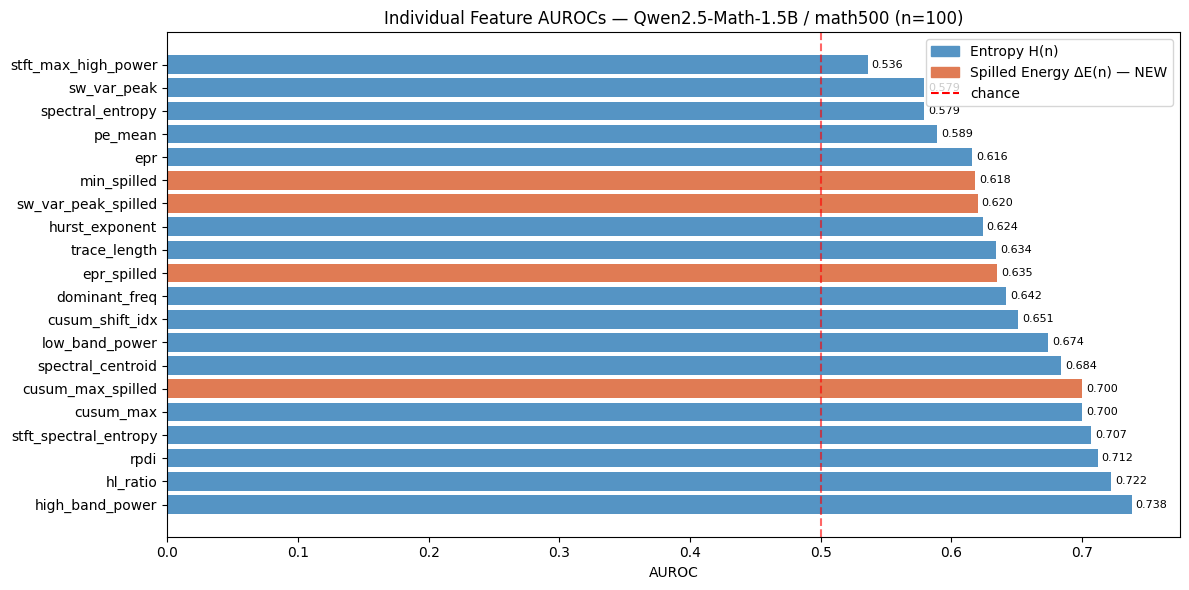

Saved feature AUC bar chart


In [9]:
# Cell 9 — Individual AUROCs for all available features
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

def orient_and_auc(vals, lbl):
    """Return max(AUC, 1-AUC) and the sign that achieves it."""
    a = roc_auc_score(lbl, vals)
    return (a, 1) if a >= 0.5 else (1 - a, -1)

auc_rows = []
for fname in ALL_20_FEATURES:
    if fname not in feats_dict:
        continue
    sign_from_config = FEATURE_SIGNS.get(fname, -1)
    a_config = roc_auc_score(labels, sign_from_config * feats_dict[fname])
    a_oracle, oracle_sign = orient_and_auc(feats_dict[fname], labels)
    auc_rows.append({
        'feature': fname,
        'auc_config_sign': round(a_config, 3),
        'auc_oracle':      round(a_oracle, 3),
        'oracle_sign':     oracle_sign,
        'sign_mismatch':   oracle_sign != sign_from_config,
        'group':           'spilled' if fname in SPILLED_FEATURES else 'entropy',
    })

auc_rows.sort(key=lambda x: -x['auc_oracle'])

print('=== Individual Feature AUROCs ===')
print(f'{"Feature":<28} {"AUC(config sign)":>17} {"AUC(oracle)":>11} {"Sign OK":>8}')
print('-' * 68)
for r in auc_rows:
    flag = '' if not r['sign_mismatch'] else '  <-- SIGN WRONG in config'
    print(f'{r["feature"]:<28} {r["auc_config_sign"]:>17.3f} {r["auc_oracle"]:>11.3f} {str(not r["sign_mismatch"]):>8}{flag}')

# Bar chart
fig, ax = plt.subplots(figsize=(12, 6))
fnames  = [r['feature'] for r in auc_rows]
aucs    = [r['auc_oracle'] for r in auc_rows]
colors  = ['#e07b54' if r['group'] == 'spilled' else '#5594c4' for r in auc_rows]
bars = ax.barh(fnames, aucs, color=colors)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.6, label='chance')
for bar, a in zip(bars, aucs):
    ax.text(a + 0.003, bar.get_y() + bar.get_height()/2, f'{a:.3f}', va='center', fontsize=8)
ax.set_xlabel('AUROC')
ax.set_title(f'Individual Feature AUROCs — {MODEL_SHORT} / {DATASET} (n={len(labels)})')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#5594c4', label='Entropy H(n)'),
    Patch(color='#e07b54', label='Spilled Energy ΔE(n) — NEW'),
    plt.Line2D([0], [0], color='red', linestyle='--', label='chance'),
])
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, f'feature_aucs_{MODEL_SHORT}_{DATASET}.png'), dpi=120)
plt.show()
print('Saved feature AUC bar chart')

---
## Section 2: Covariance Matrix Structure vs. Theory

The Jaffé-Fetaya-Nadler 2016 paper predicts:
- **Diagonal**: R_ii = 1 (z-scored by construction)
- **Within-group off-diagonal**: R_ij = β_i^{on} · β_j^{on} > α_i · α_j (features sharing a latent information source)
- **Cross-group off-diagonal**: R_ij ≈ α_i · α_j = (2·AUC_i − 1)(2·AUC_j − 1) (conditionally independent given y)

**If features were perfectly partitioned into groups**, we'd see:
- Block structure in R: high values within each group, low values across groups
- `within/cross ratio >> 1`

**Our hypothesis**: H(n)-based features (epr, cusum_max, sw_var_peak) form one group; ΔE(n)-based features form a second group; STFT/RPDI features may form a third group.

In [10]:
# Cell 10 — Covariance matrix R and theoretical rank-1 comparison
from scipy.stats import spearmanr

def build_R_continuous(feats_d, feat_names, signs):
    """Build oriented z-scored covariance matrix R."""
    views = []
    for f in feat_names:
        if f not in feats_d:
            continue
        v = signs.get(f, -1) * feats_d[f].copy()
        v = (v - v.mean()) / (v.std() + 1e-9)
        views.append(v)
    X  = np.column_stack(views)          # n_samples × M
    R  = np.corrcoef(X.T)                # M × M  (Pearson on z-scored = Pearson)
    return R, views

def build_R_theory(aucs):
    """Rank-1 prediction: R_ij^theory = (2*AUC_i - 1)(2*AUC_j - 1)."""
    betas = np.array([2*a - 1 for a in aucs])
    R_th  = np.outer(betas, betas)
    np.fill_diagonal(R_th, 1.0)
    return R_th

# Use all available features from ALL_20
avail_feats  = [f for f in ALL_20_FEATURES if f in feats_dict]
avail_aucs   = {r['feature']: r['auc_oracle'] for r in auc_rows}
feat_aucs    = [avail_aucs[f] for f in avail_feats]

R_cont, views  = build_R_continuous(feats_dict, avail_feats, FEATURE_SIGNS)
R_theory       = build_R_theory(feat_aucs)
R_residual     = R_cont - R_theory

M = len(avail_feats)
off_mask = ~np.eye(M, dtype=bool)

print(f'M = {M} features')
print(f'R diagonal: mean={np.diag(R_cont).mean():.3f}  (should be 1.0)')
print(f'R off-diag: mean={R_cont[off_mask].mean():.3f}  std={R_cont[off_mask].std():.3f}')
print(f'R_theory off-diag: mean={R_theory[off_mask].mean():.3f}')
print(f'Residual off-diag: mean={R_residual[off_mask].mean():.3f}  std={R_residual[off_mask].std():.3f}')
print()

# Within-group analysis: separate H(n) vs ΔE(n) features
ent_idx  = [i for i, f in enumerate(avail_feats) if f in ENTROPY_FEATURES]
spil_idx = [i for i, f in enumerate(avail_feats) if f in SPILLED_FEATURES]

def mean_off_diag(R, idx):
    sub = R[np.ix_(idx, idx)]
    mask = ~np.eye(len(idx), dtype=bool)
    return sub[mask].mean() if mask.sum() > 0 else float('nan')

def mean_cross(R, idx_a, idx_b):
    sub = R[np.ix_(idx_a, idx_b)]
    return sub.mean()

within_ent  = mean_off_diag(R_cont, ent_idx)
within_spil = mean_off_diag(R_cont, spil_idx)
cross_es    = mean_cross(R_cont, ent_idx, spil_idx)

print('--- Within/cross correlation (R matrix, oriented features) ---')
print(f'  Within entropy features:  {within_ent:.3f}')
print(f'  Within spilled features:  {within_spil:.3f}')
print(f'  Cross (ent vs spilled):   {cross_es:.3f}')
print(f'  Ratio (within_ent / cross): {within_ent / (abs(cross_es) + 1e-6):.2f}  (>2 = good separation)')
print(f'  Ratio (within_spil / cross): {within_spil / (abs(cross_es) + 1e-6):.2f}')

M = 20 features
R diagonal: mean=1.000  (should be 1.0)
R off-diag: mean=0.327  std=0.343
R_theory off-diag: mean=0.087
Residual off-diag: mean=0.240  std=0.326

--- Within/cross correlation (R matrix, oriented features) ---
  Within entropy features:  0.345
  Within spilled features:  0.225
  Cross (ent vs spilled):   0.302
  Ratio (within_ent / cross): 1.14  (>2 = good separation)
  Ratio (within_spil / cross): 0.74


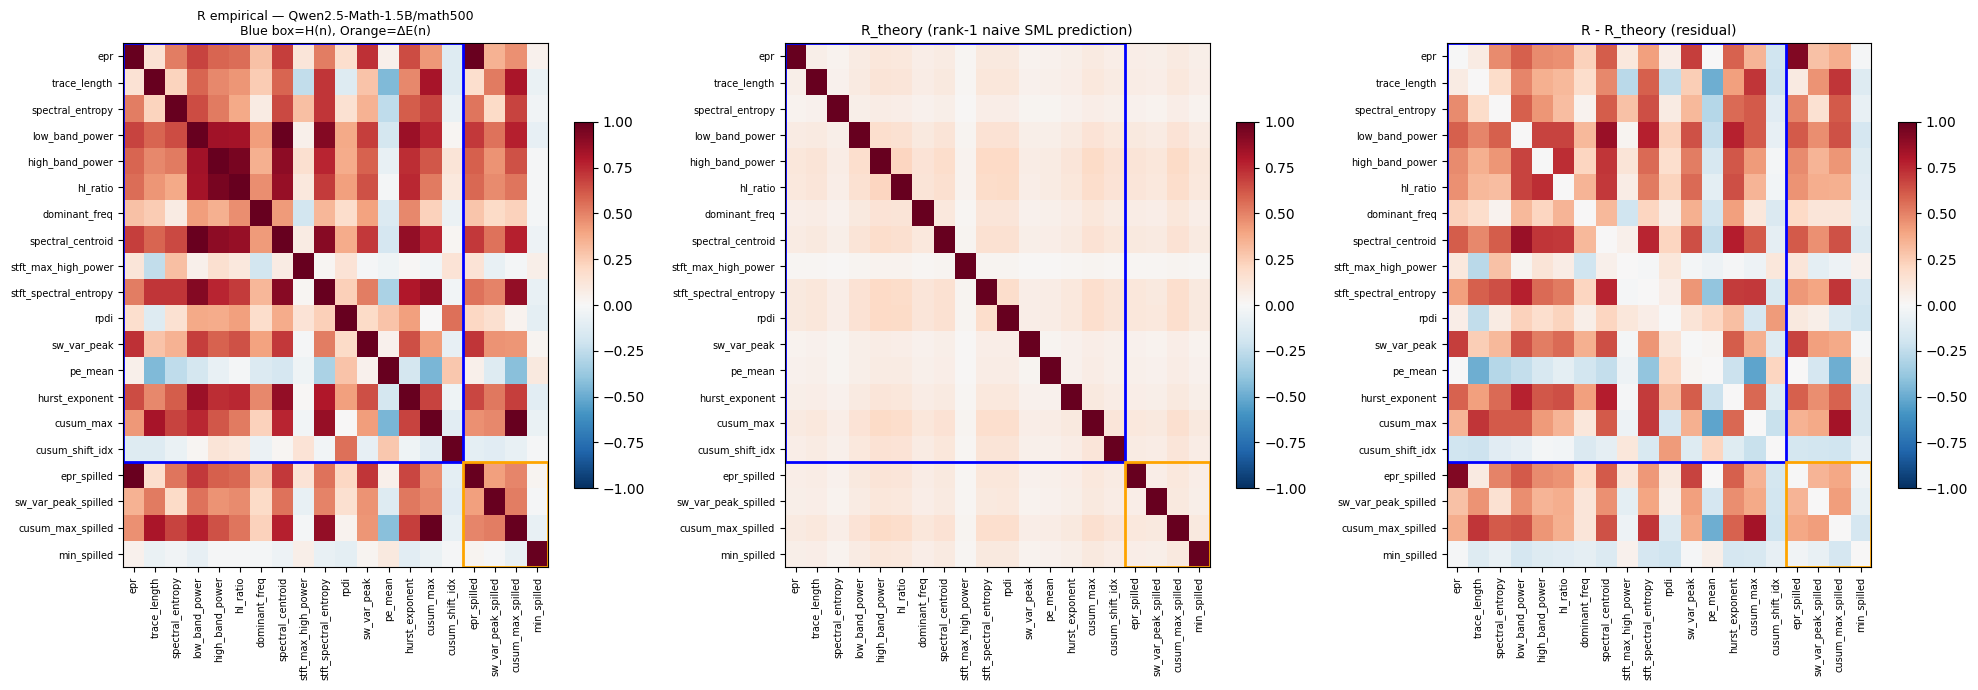

Saved covariance heatmaps


In [11]:
# Cell 11 — Covariance matrix heatmaps
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

def draw_heatmap(ax, mat, title, vmin=None, vmax=None, cmap='RdBu_r', center=None):
    norm = TwoSlopeNorm(vmin=vmin, vcenter=center or 0, vmax=vmax) if center is not None else None
    im = ax.imshow(mat, cmap=cmap, aspect='auto', norm=norm,
                   vmin=vmin if norm is None else None, vmax=vmax if norm is None else None)
    ax.set_xticks(range(len(avail_feats)))
    ax.set_yticks(range(len(avail_feats)))
    ax.set_xticklabels(avail_feats, rotation=90, fontsize=7)
    ax.set_yticklabels(avail_feats, fontsize=7)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.7)
    # Draw group boundary boxes
    n_ent  = len(ent_idx)
    n_spil = len(spil_idx)
    ax.add_patch(mpatches.Rectangle((-0.5, -0.5), n_ent, n_ent,
                                    fill=False, edgecolor='blue', lw=2, label='H(n) group'))
    if n_spil > 0:
        ax.add_patch(mpatches.Rectangle((n_ent - 0.5, n_ent - 0.5), n_spil, n_spil,
                                        fill=False, edgecolor='orange', lw=2, label='ΔE(n) group'))

draw_heatmap(axes[0], R_cont,     f'R (empirical, {M} features)', vmin=-1, vmax=1, center=0)
draw_heatmap(axes[1], R_theory,   'R_theory (rank-1 naive SML prediction)', vmin=-1, vmax=1, center=0)
draw_heatmap(axes[2], R_residual, 'R - R_theory (residual)', vmin=-1, vmax=1, center=0)

axes[0].set_title(f'R empirical — {MODEL_SHORT}/{DATASET}\nBlue box=H(n), Orange=ΔE(n)', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, f'covariance_heatmaps_{MODEL_SHORT}_{DATASET}.png'), dpi=120)
plt.show()
print('Saved covariance heatmaps')

---
## Section 3: L-SML Group Detection — how features cluster

Running L-SML group detection on M=20 features...
K selected = 6

=== Group assignment (L-SML spectral clustering) ===
  Group 0: ['spectral_entropy', 'dominant_freq', 'stft_max_high_power']
           H(n) features: ['spectral_entropy', 'dominant_freq', 'stft_max_high_power']
           AUROCs: ['0.579', '0.642', '0.536']

  Group 1: ['trace_length', 'stft_spectral_entropy', 'pe_mean', 'cusum_max', 'sw_var_peak_spilled', 'cusum_max_spilled']
           H(n) features: ['trace_length', 'stft_spectral_entropy', 'pe_mean', 'cusum_max']
           ΔE(n) features: ['sw_var_peak_spilled', 'cusum_max_spilled']
           AUROCs: ['0.634', '0.707', '0.589', '0.700', '0.620', '0.700']

  Group 2: ['low_band_power', 'high_band_power', 'hl_ratio', 'spectral_centroid', 'hurst_exponent']
           H(n) features: ['low_band_power', 'high_band_power', 'hl_ratio', 'spectral_centroid', 'hurst_exponent']
           AUROCs: ['0.674', '0.738', '0.722', '0.684', '0.624']

  Group 3: ['min_spilled']
      

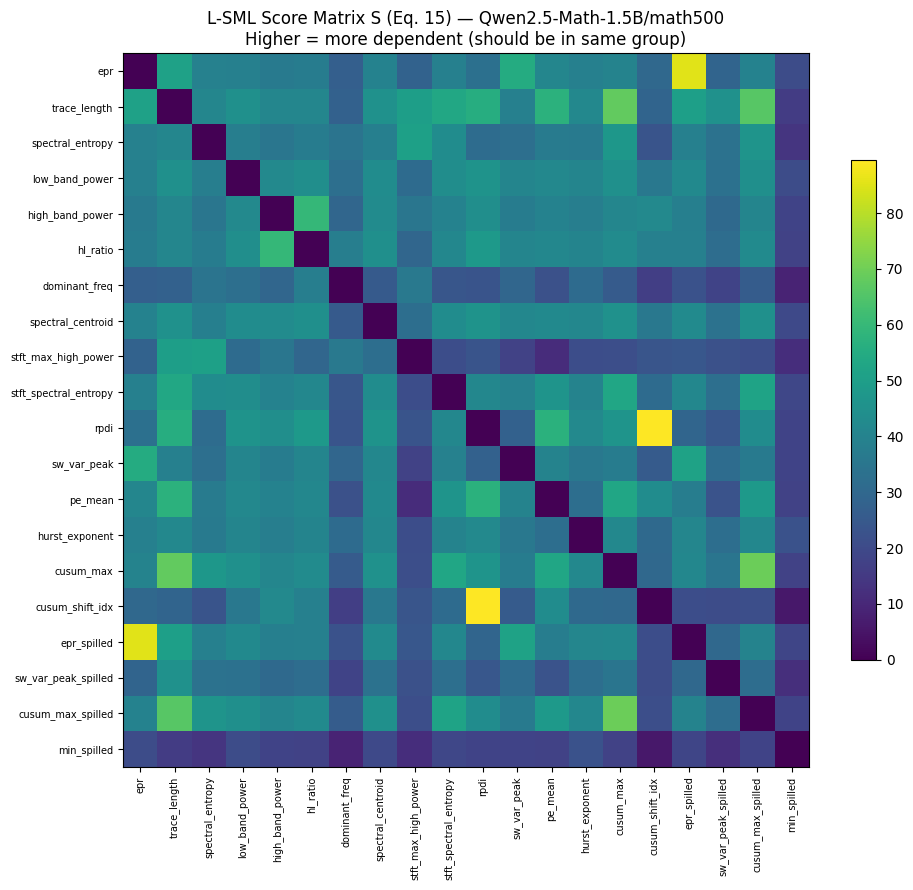

Saved score matrix


In [12]:
# Cell 12 — L-SML group detection on all 20 features
# Shows which features end up in which group under the spectral clustering used by L-SML
from spectral_utils import detect_dependent_groups

# Build oriented z-scored views (same as lsml_continuous_pipeline does internally)
def build_oriented_views(feats_d, feat_names, signs):
    views, names = [], []
    for f in feat_names:
        if f not in feats_d:
            continue
        v = signs.get(f, -1) * feats_d[f].copy()
        v = (v - v.mean()) / (v.std() + 1e-9)
        views.append(v)
        names.append(f)
    return views, names

views_all, names_all = build_oriented_views(feats_dict, avail_feats, FEATURE_SIGNS)

print(f'Running L-SML group detection on M={len(views_all)} features...')
# detect_dependent_groups returns (best_K, assignment_c, best_resid, score_matrix_s)
K_all, groups_all, _, _ = detect_dependent_groups(views_all)

print(f'K selected = {K_all}')
print()

# Display: which features ended up in which group
from collections import defaultdict
group_members = defaultdict(list)
for feat, grp in zip(names_all, groups_all):
    group_members[grp].append(feat)

print('=== Group assignment (L-SML spectral clustering) ===')
for g in sorted(group_members):
    members = group_members[g]
    # Classify members by source
    ent_m   = [f for f in members if f in ENTROPY_FEATURES]
    spil_m  = [f for f in members if f in SPILLED_FEATURES]
    grp_aucs = [avail_aucs.get(f, 0) for f in members]
    print(f'  Group {g}: {members}')
    if ent_m:  print(f'           H(n) features: {ent_m}')
    if spil_m: print(f'           ΔE(n) features: {spil_m}')
    print(f'           AUROCs: {[f"{a:.3f}" for a, f in zip(grp_aucs, members)]}')
    print()

# Score matrix (Eq. 15 from paper) — shows which pairs are most dependent
# s_ij = sum_{k,l!=i,j} |r_ij*r_kl - r_il*r_kj|
def compute_score_matrix(R):
    m = R.shape[0]
    S = np.zeros((m, m))
    for i in range(m):
        for j in range(i+1, m):
            s = 0.0
            for k in range(m):
                for l in range(m):
                    if l == i or l == j:
                        continue
                    s += abs(R[i,j]*R[k,l] - R[i,l]*R[k,j])
            S[i,j] = S[j,i] = s
    return S

print('Computing score matrix S (Eq. 15)...')
S = compute_score_matrix(R_cont)
print('Score matrix S (higher = more dependent pair):')

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(S, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(names_all)))
ax.set_yticks(range(len(names_all)))
ax.set_xticklabels(names_all, rotation=90, fontsize=7)
ax.set_yticklabels(names_all, fontsize=7)
ax.set_title(f'L-SML Score Matrix S (Eq. 15) — {MODEL_SHORT}/{DATASET}\nHigher = more dependent (should be in same group)')
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, f'score_matrix_{MODEL_SHORT}_{DATASET}.png'), dpi=120)
plt.show()
print('Saved score matrix')

In [14]:
# Cell 13 — Per-group virtual classifier AUROCs after L-SML fusion within each detected group
# This shows what each group contributes to the final fusion
from spectral_utils import sml_fuse_signed

print('=== Per-group virtual classifier AUROCs ===')
group_virtual_aucs = {}
for g in sorted(group_members):
    members = group_members[g]
    grp_views = [v for v, n in zip(views_all, names_all) if n in members]
    if len(grp_views) < 2:
        # Singleton — use the raw view directly
        virtual = grp_views[0]
        method  = 'singleton'
    else:
        virtual, _ = sml_fuse_signed(*grp_views)  # SML within group; returns (scores, weights)
        method  = 'SML'
    a = roc_auc_score(labels, virtual)
    a = max(a, 1 - a)  # orient
    group_virtual_aucs[g] = a
    member_source = [('ΔE' if f in SPILLED_FEATURES else 'H') for f in members]
    print(f'  Group {g} [{method}]: AUROC={a:.3f}  members={list(zip(members, member_source))}')

# Overall L-SML fusion
lsml_scores, meta = lsml_continuous_pipeline(feats_dict, avail_feats, FEATURE_SIGNS)
a_lsml = roc_auc_score(labels, lsml_scores)
a_lsml = max(a_lsml, 1 - a_lsml)

best_ind_auc = max(r['auc_oracle'] for r in auc_rows)
best_ind_feat = [r['feature'] for r in auc_rows if r['auc_oracle'] == best_ind_auc][0]

print()
print(f'Best individual ({best_ind_feat}): {best_ind_auc:.3f}')
print(f'L-SML (all {M} features, continuous): {a_lsml:.3f}  K={meta["K"]}')
print(f'Lift vs best individual: {(a_lsml - best_ind_auc)*100:+.2f}pp')

=== Per-group virtual classifier AUROCs ===
  Group 0 [SML]: AUROC=0.564  members=[('spectral_entropy', 'H'), ('dominant_freq', 'H'), ('stft_max_high_power', 'H')]
  Group 1 [SML]: AUROC=0.682  members=[('trace_length', 'H'), ('stft_spectral_entropy', 'H'), ('pe_mean', 'H'), ('cusum_max', 'H'), ('sw_var_peak_spilled', 'ΔE'), ('cusum_max_spilled', 'ΔE')]
  Group 2 [SML]: AUROC=0.700  members=[('low_band_power', 'H'), ('high_band_power', 'H'), ('hl_ratio', 'H'), ('spectral_centroid', 'H'), ('hurst_exponent', 'H')]
  Group 3 [singleton]: AUROC=0.618  members=[('min_spilled', 'ΔE')]
  Group 4 [SML]: AUROC=0.638  members=[('epr', 'H'), ('sw_var_peak', 'H'), ('epr_spilled', 'ΔE')]
  Group 5 [SML]: AUROC=0.702  members=[('rpdi', 'H'), ('cusum_shift_idx', 'H')]

Best individual (high_band_power): 0.738
L-SML (all 20 features, continuous): 0.693  K=6
Lift vs best individual: -4.47pp


---
## Section 4: Sign Validation for Spilled Features

Check whether the initial sign estimates in FEATURE_SIGNS are correct for this model/dataset.

In [15]:
# Cell 14 — Validate signs for all features (especially spilled)
print('=== Sign validation (oracle sign vs config sign) ===')
print(f'{"Feature":<28} {"Config sign":>12} {"Oracle sign":>12} {"Status":>8}')
print('-' * 65)
sign_issues = []
for r in sorted(auc_rows, key=lambda x: x['feature']):
    config_sign = FEATURE_SIGNS.get(r['feature'], -1)
    oracle_sign = r['oracle_sign']
    status = 'OK' if oracle_sign == config_sign else 'MISMATCH'
    if oracle_sign != config_sign:
        sign_issues.append(r['feature'])
    print(f'{r["feature"]:<28} {config_sign:>12} {oracle_sign:>12} {status:>8}')

if sign_issues:
    print()
    print(f'Sign mismatches ({len(sign_issues)}): {sign_issues}')
    print('>>> Update FEATURE_SIGNS dict for these features before L-SML fusion')
else:
    print()
    print('All signs correct for this model/dataset.')

=== Sign validation (oracle sign vs config sign) ===
Feature                       Config sign  Oracle sign   Status
-----------------------------------------------------------------
cusum_max                              -1           -1       OK
cusum_max_spilled                      -1           -1       OK
cusum_shift_idx                        -1           -1       OK
dominant_freq                           1            1       OK
epr                                    -1           -1       OK
epr_spilled                            -1           -1       OK
high_band_power                         1            1       OK
hl_ratio                                1            1       OK
hurst_exponent                         -1           -1       OK
low_band_power                         -1           -1       OK
min_spilled                            -1           -1       OK
pe_mean                                -1           -1       OK
rpdi                                   -1        

---
## Section 5: Pipeline Comparison

In [16]:
# Cell 15 — Compare all fusion strategies on this new dataset
from spectral_utils import best_nadler_on

results_table = []

# 1. Best individual
results_table.append(('Best individual', best_ind_auc, f'feat={best_ind_feat}'))

# 2. Simple average (z-scored, GOOD_FEATURES)
good_avail = [f for f in GOOD_FEATURES if f in feats_dict]
good_views = [FEATURE_SIGNS.get(f, -1) * zscore(feats_dict[f]) for f in good_avail]
avg_scores = np.mean(np.column_stack(good_views), axis=1)
a_avg = max(roc_auc_score(labels, avg_scores), roc_auc_score(labels, -avg_scores))
results_table.append(('Avg (GOOD_FEATURES)', a_avg, f'M={len(good_avail)}'))

# 3. Current pipeline: binarized + lsml_fuse (GOOD_FEATURES)
bin_feats = binarize_classifiers({f: feats_dict[f] for f in good_avail}, FEATURE_SIGNS)
bin_filt  = {f: bin_feats[f] for f in good_avail}
cur_scores, cur_meta = lsml_continuous_pipeline(feats_dict, GOOD_FEATURES, FEATURE_SIGNS)
a_cur = max(roc_auc_score(labels, cur_scores), roc_auc_score(labels, -cur_scores))
results_table.append(('L-SML continuous (GOOD_5)', a_cur, f'K={cur_meta["K"]}'))

# 4. L-SML continuous: GOOD_FEATURES + spilled energy features
good_plus_spilled = GOOD_FEATURES + [f for f in SPILLED_FEATURES if f in feats_dict]
gps_scores, gps_meta = lsml_continuous_pipeline(feats_dict, good_plus_spilled, FEATURE_SIGNS)
a_gps = max(roc_auc_score(labels, gps_scores), roc_auc_score(labels, -gps_scores))
results_table.append(('L-SML continuous (5+4 spilled)', a_gps, f'K={gps_meta["K"]}'))

# 5. L-SML continuous: ALL 20 features
all20_scores, all20_meta = lsml_continuous_pipeline(feats_dict, avail_feats, FEATURE_SIGNS)
a_all20 = max(roc_auc_score(labels, all20_scores), roc_auc_score(labels, -all20_scores))
results_table.append(('L-SML continuous (all-20)', a_all20, f'K={all20_meta["K"]}'))

print('=== Pipeline Comparison ===')
print(f'{"Pipeline":<35} {"AUROC":>8} {"vs best-ind":>12} {"Notes"}')
print('-' * 75)
for name, auc, note in results_table:
    delta = f'{(auc - best_ind_auc)*100:+.2f}pp'
    print(f'{name:<35} {auc:>8.3f} {delta:>12}   {note}')

print()
print('Key: does adding spilled energy features help? Lift of (5+4 spilled) vs (GOOD_5):',
      f'{(a_gps - a_cur)*100:+.2f}pp')
print('Key: does all-20 beat 5+4?',
      f'{(a_all20 - a_gps)*100:+.2f}pp')

=== Pipeline Comparison ===
Pipeline                               AUROC  vs best-ind Notes
---------------------------------------------------------------------------
Best individual                        0.738      +0.00pp   feat=high_band_power
Avg (GOOD_FEATURES)                    0.648      -9.02pp   M=5
L-SML continuous (GOOD_5)              0.649      -8.94pp   K=2
L-SML continuous (5+4 spilled)         0.656      -8.23pp   K=4
L-SML continuous (all-20)              0.693      -4.47pp   K=6

Key: does adding spilled energy features help? Lift of (5+4 spilled) vs (GOOD_5): +0.71pp
Key: does all-20 beat 5+4? +3.76pp


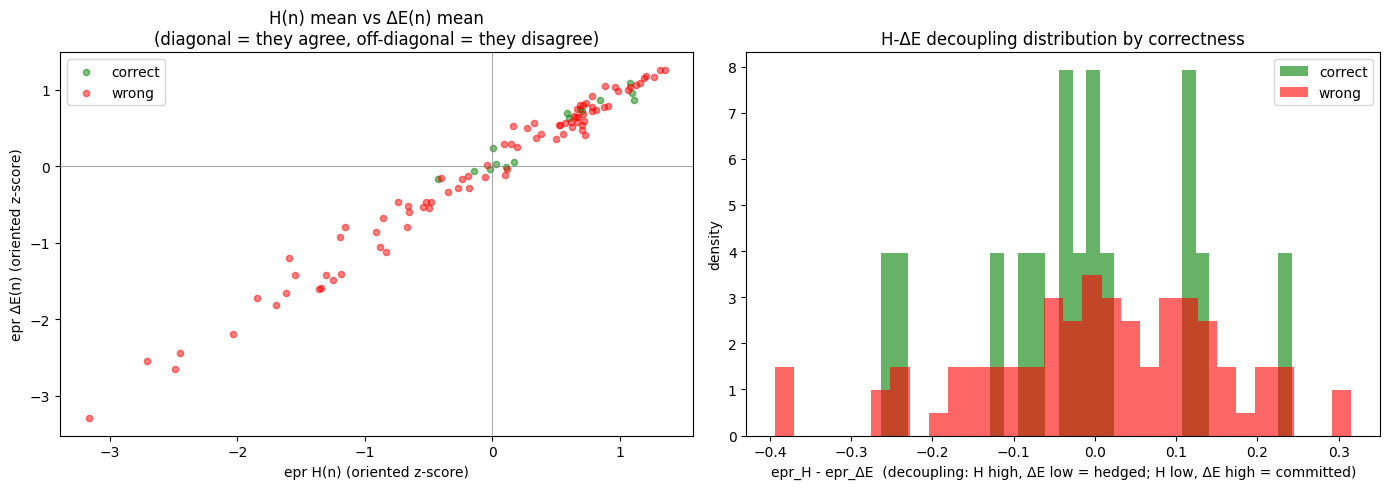

Saved H vs ΔE scatter
Pearson corr(epr_H, epr_ΔE) = 0.989
If |corr| > 0.8, H and ΔE are too similar (no new info from spilled features)
If |corr| < 0.5, spilled features carry independent information — good for L-SML


In [17]:
# Cell 16 — ΔE(n) vs H(n) scatter: visualize where they agree/disagree
# This is the key diagnostic: samples where ΔE and H diverge

if 'epr_spilled' in feats_dict:
    epr_h  = FEATURE_SIGNS['epr']         * zscore(feats_dict['epr'])
    epr_de = FEATURE_SIGNS['epr_spilled'] * zscore(feats_dict['epr_spilled'])

    correct_mask = labels == 1
    wrong_mask   = labels == 0

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: scatter H vs ΔE
    ax = axes[0]
    ax.scatter(epr_h[correct_mask], epr_de[correct_mask], alpha=0.5, s=20, c='green', label='correct')
    ax.scatter(epr_h[wrong_mask],   epr_de[wrong_mask],   alpha=0.5, s=20, c='red',   label='wrong')
    ax.set_xlabel('epr H(n) (oriented z-score)')
    ax.set_ylabel('epr ΔE(n) (oriented z-score)')
    ax.set_title('H(n) mean vs ΔE(n) mean\n(diagonal = they agree, off-diagonal = they disagree)')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.legend()

    # Right: difference H - ΔE (decoupling signal)
    diff = epr_h - epr_de
    ax2  = axes[1]
    ax2.hist(diff[correct_mask], bins=30, alpha=0.6, color='green', label='correct', density=True)
    ax2.hist(diff[wrong_mask],   bins=30, alpha=0.6, color='red',   label='wrong',   density=True)
    ax2.set_xlabel('epr_H - epr_ΔE  (decoupling: H high, ΔE low = hedged; H low, ΔE high = committed)')
    ax2.set_ylabel('density')
    ax2.set_title('H-ΔE decoupling distribution by correctness')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(RES_DIR, f'HvsDE_scatter_{MODEL_SHORT}_{DATASET}.png'), dpi=120)
    plt.show()
    print('Saved H vs ΔE scatter')

    # Report Pearson correlation between H and ΔE
    corr_hde = np.corrcoef(feats_dict['epr'], feats_dict['epr_spilled'])[0,1]
    print(f'Pearson corr(epr_H, epr_ΔE) = {corr_hde:.3f}')
    print('If |corr| > 0.8, H and ΔE are too similar (no new info from spilled features)')
    print('If |corr| < 0.5, spilled features carry independent information — good for L-SML')

In [18]:
# Cell 17 — Save all results
RESULTS_PATH = os.path.join(RES_DIR, f'spilled_verify_results_{MODEL_SHORT}_{DATASET}.pkl')

results_summary = {
    'model':         MODEL_SHORT,
    'dataset':       DATASET,
    'n_samples':     len(labels),
    'accuracy':      float(labels.mean()),
    'max_new_tokens': MAX_NEW_TOKENS,
    'n_saturated':   int((trace_lengths >= MAX_NEW_TOKENS).sum()),
    'feature_aucs':  {r['feature']: r['auc_oracle'] for r in auc_rows},
    'sign_mismatches': sign_issues,
    'R_cont':        R_cont,
    'R_theory':      R_theory,
    'avail_feats':   avail_feats,
    'group_members': dict(group_members),
    'K_selected':    K_all,
    'pipeline_comparison': {name: auc for name, auc, _ in results_table},
    'within_ent':    float(within_ent),
    'within_spil':   float(within_spil),
    'cross_es':      float(cross_es),
}

with open(RESULTS_PATH, 'wb') as f:
    pickle.dump(results_summary, f)
print(f'Results saved to {RESULTS_PATH}')

print()
print('=== SUMMARY ===')
print(f'Model: {MODEL_SHORT} / Dataset: {DATASET}')
print(f'Trace saturation: {results_summary["n_saturated"]/len(labels):.1%} (max_new={MAX_NEW_TOKENS})')
print(f'Best individual:       {best_ind_auc:.3f}')
print(f'L-SML GOOD_5:          {a_cur:.3f}')
print(f'L-SML GOOD_5 + spilled: {a_gps:.3f}  (delta: {(a_gps-a_cur)*100:+.2f}pp)')
print(f'L-SML all-20:          {a_all20:.3f}')
print(f'Covariance: within_H={within_ent:.3f}, within_ΔE={within_spil:.3f}, cross={cross_es:.3f}')
print(f'  within/cross ratio (H):  {within_ent/(abs(cross_es)+1e-6):.2f}')
print(f'  within/cross ratio (ΔE): {within_spil/(abs(cross_es)+1e-6):.2f}')

Results saved to /content/drive/MyDrive/hallucination_detection/phase_spilled_verify/spilled_verify_results_Qwen2.5-Math-1.5B_math500.pkl

=== SUMMARY ===
Model: Qwen2.5-Math-1.5B / Dataset: math500
Trace saturation: 2.0% (max_new=2048)
Best individual:       0.738
L-SML GOOD_5:          0.649
L-SML GOOD_5 + spilled: 0.656  (delta: +0.71pp)
L-SML all-20:          0.693
Covariance: within_H=0.345, within_ΔE=0.225, cross=0.302
  within/cross ratio (H):  1.14
  within/cross ratio (ΔE): 0.74
